C:\Users\admin\AppData\Local\Temp\ipykernel_32928\1698524783.py:25: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Natural Breaks classification bins: [  3612.  14638.  28766.  52206.  91179. 118445.]


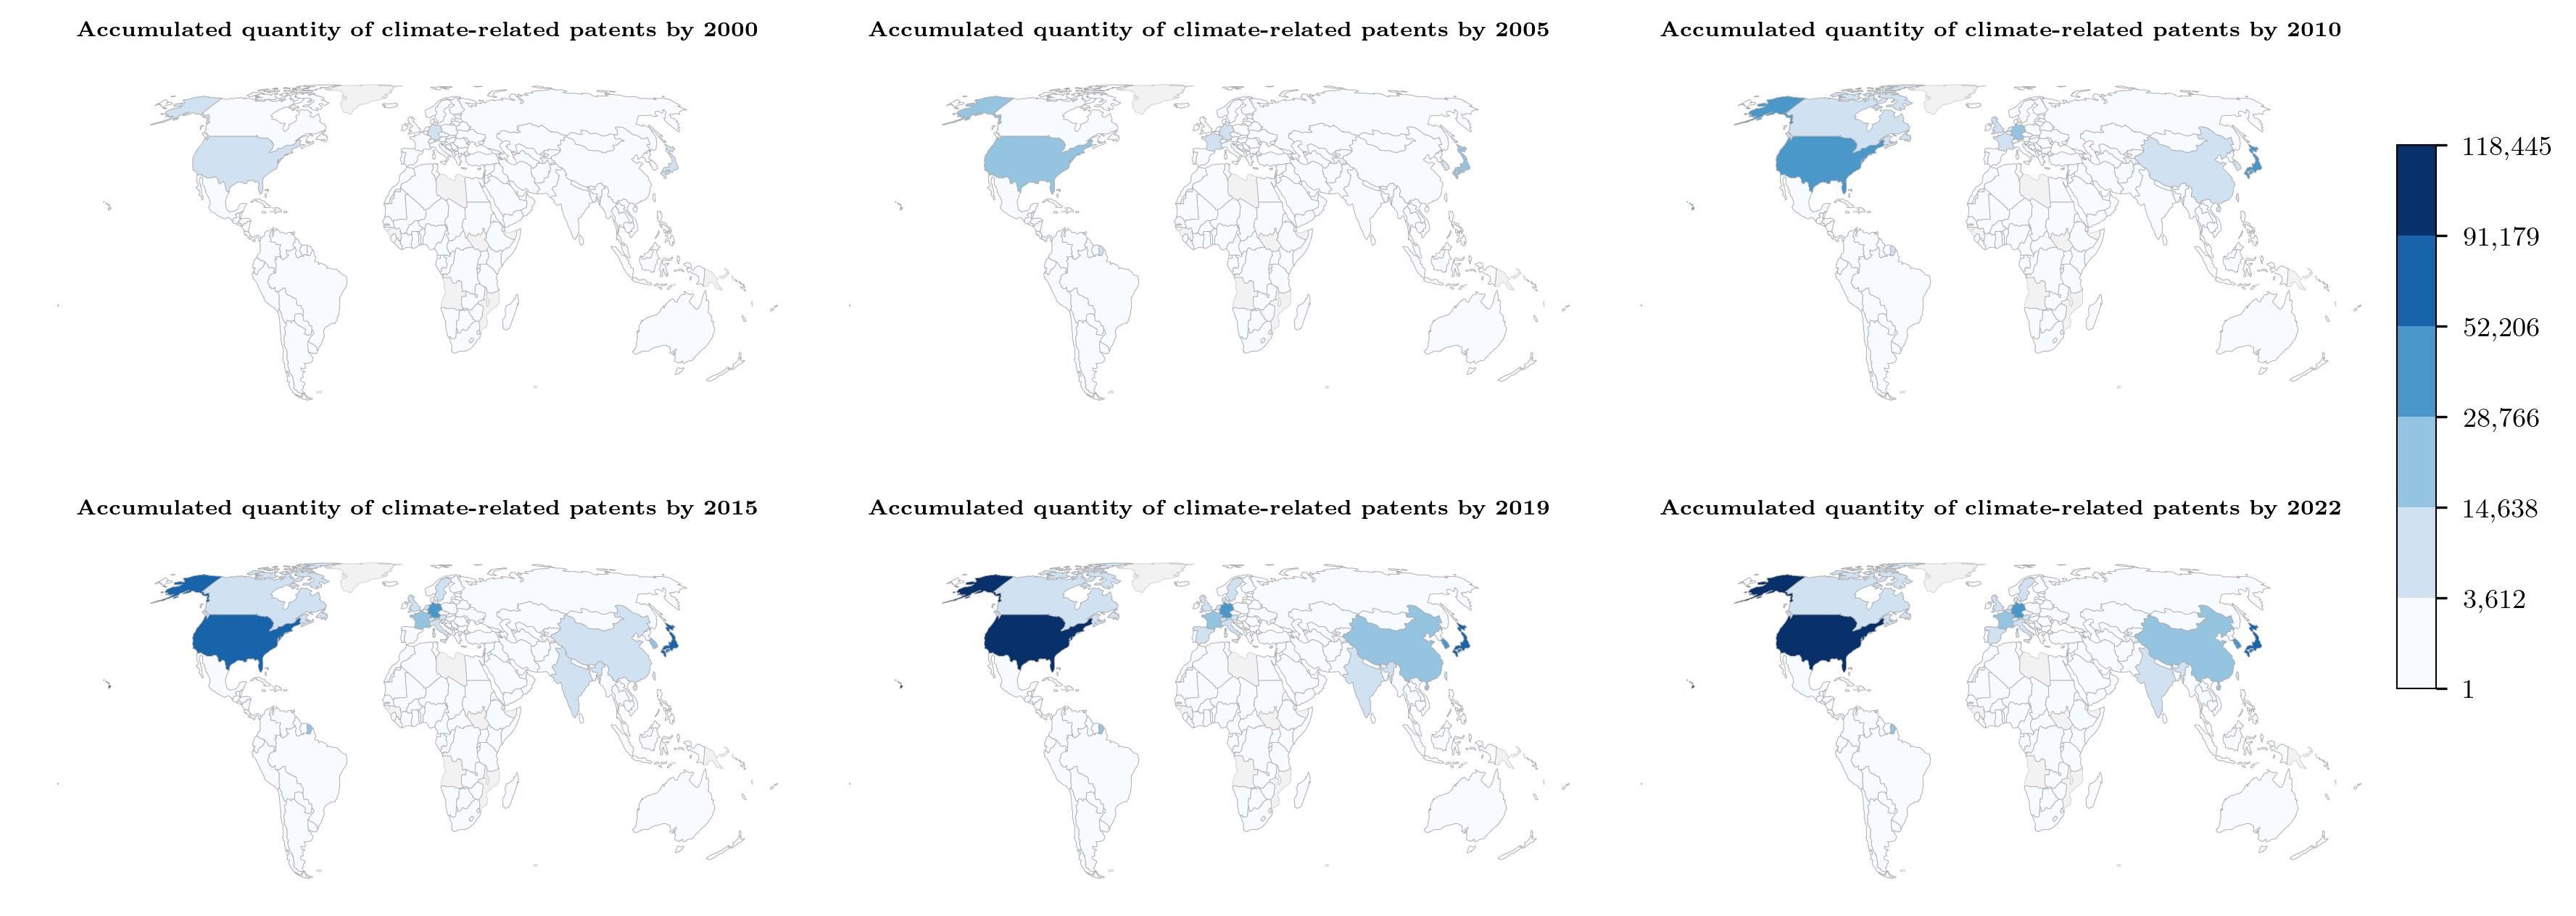

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import mapclassify

# ==========================================
# 1. 設置學術風格
# ==========================================
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 12,
    "figure.dpi": 300,
})

# ==========================================
# 2. 數據處理
# ==========================================
# 讀取地圖
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

# 讀取專利數據
df = pd.read_csv("countries_patent_count.csv")

# 確保年份列名正確
year_col = 'earliest_year' 
if year_col not in df.columns:
    for col in df.columns:
        if 'year' in col.lower():
            year_col = col
            break

# 定義要展示的時間節點
target_years = [1990, 1995, 2000, 2005, 2010, 2015, 2019, 2022]

# 收集所有年份的累計專利數據用於計算全局 natural breaks
all_accumulated_data = []
for year in target_years:
    df_accumulated = df[df[year_col] <= year].groupby('countries_3digit')['num_patents'].sum().reset_index()
    df_accumulated['year'] = year
    all_accumulated_data.append(df_accumulated)

df_all = pd.concat(all_accumulated_data, ignore_index=True)

# 計算全局 Natural Breaks (使用所有年份的數據)
valid_patents = df_all[df_all['num_patents'] > 0]['num_patents']
classifier = mapclassify.NaturalBreaks(valid_patents, k=6)
breaks = classifier.bins

print(f"Natural Breaks classification bins: {breaks}")

# ==========================================
# 3. 繪製 Small Multiples (2行3列)
# ==========================================
fig, axes = plt.subplots(3, 3, figsize=(12, 5))
axes = axes.flatten()

for i, year in enumerate(target_years):
    ax = axes[i]
    
    # --- A. 計算截止到該年份的累計數量 (Accumulated Stock) ---
    df_accumulated = df[df[year_col] <= year].groupby('countries_3digit')['num_patents'].sum().reset_index()
    
    # 合併到地圖數據
    world_merged = world.merge(df_accumulated, left_on='iso_a3', right_on='countries_3digit', how='left')
    
    # 投影轉換 (Equal Earth)
    world_proj = world_merged.to_crs('+proj=eqearth')
    
    # --- B. 繪圖 ---
    # 1. 繪製底圖 (淺灰)
    world_proj.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.2)
    
    # 2. 繪製數據 (Choropleth with Natural Breaks)
    world_proj.dropna(subset=['num_patents']).plot(
        ax=ax,
        column='num_patents',
        cmap='Blues',
        classification_kwds={'bins': breaks},  # 使用全局統一的斷點
        scheme='user_defined',  # 使用自定義斷點
        edgecolor='#aaaaaa',
        linewidth=0.2,
        legend=False
    )
    
    # 3. 設置標題和移除坐標軸
    ax.set_title(fr"\textbf{{Accumulated quantity of climate-related patents by {year}}}", fontsize=7, pad=2)
    ax.set_axis_off()

# ==========================================
# 4. 添加統一 Colorbar (使用 Natural Breaks 的斷點)
# ==========================================
cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])

# 創建離散色階
cmap = plt.cm.Blues
patent_min = valid_patents.min()
bounds = [patent_min] + list(breaks)
norm_discrete = mcolors.BoundaryNorm(bounds, cmap.N)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_discrete)
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', spacing='uniform')

# Colorbar 樣式
# cbar.set_label(
#     r'\textbf{Accumulated Patent Count}',
#     rotation=270,
#     labelpad=20,
#     fontsize=10
# )
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(labelsize=9)

# 設置刻度標籤為斷點值（使用整數格式）
cbar.set_ticks(bounds)
cbar.set_ticklabels([f'{int(b):,}' for b in bounds])

# 調整佈局
plt.subplots_adjust(wspace=0.0, hspace=0.0, left=0.01, right=0.92, bottom=0.0)

plt.show()

In [47]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ==========================================
# 1. 設置學術風格
# ==========================================
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 12,
    "figure.dpi": 300,
})

# ==========================================
# 2. 數據處理
# ==========================================
# 讀取地圖
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

# 讀取專利質量數據
df_quality = pd.read_csv("oecd_patent_quality_country_year.csv")
# 讀取專利數量數據（用於計算前99%）
df_count = pd.read_excel("expanded_patent_count.xlsx")

# 確保年份列名正確
year_col = 'earliest_year'
if year_col not in df_count.columns:
    for col in df_count.columns:
        if 'year' in col.lower():
            year_col = col
            break

# 重命名列以便合併
df_count_renamed = df_count.rename(columns={year_col: 'appln_filing_year'})
time_periods = [
    ([1997, 1998, 1999, 2000], "1997-2000"),
    ([2001, 2002, 2003, 2004, 2005], "2001-2005"),
    ([2006, 2007, 2008, 2009, 2010], "2006-2010"),
    ([2011, 2012, 2013, 2014, 2015], "2011-2015"),
    ([2016, 2017, 2018, 2019], "2016-2019"),
    ([2020, 2021, 2022], "2020-2022")
]

C:\Users\admin\AppData\Local\Temp\ipykernel_32928\2980623820.py:24: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


In [48]:
# ==========================================
# 3. 為每個時間段計算平均質量指數（僅前99%國家）
# ==========================================
period_data = []

for years, label in time_periods:
    # 步驟1: 篩選該時間段的專利數量數據，計算每個國家的總專利數
    df_count_period = df_count_renamed[
        df_count_renamed['appln_filing_year'].isin(years)
    ].copy()
    
    country_patent_sum = df_count_period.groupby('countries_3digit').agg({
        'num_patents': 'sum'
    }).reset_index()
    
    # 步驟2: 按專利數量排序，計算累計百分比，找出前99%的國家
    country_patent_sum = country_patent_sum.sort_values('num_patents', ascending=False)
    country_patent_sum['cumsum'] = (
        country_patent_sum['num_patents'].cumsum() / country_patent_sum['num_patents'].sum()
    )
    
    # 只保留累計百分比 <= 0.99 的國家（前99%專利來源國）
    valid_countries = country_patent_sum[
        country_patent_sum['cumsum'] <= 0.99
    ]['countries_3digit'].tolist()
    
    # 步驟3: 篩選該時間段的質量數據，只保留前99%國家
    df_quality_period = df_quality[
        (df_quality['appln_filing_year'].isin(years)) &
        (df_quality['country_code_3digit'].isin(valid_countries))
    ].copy()
    
    # 步驟4: 計算這些國家的平均質量指數（只考慮有專利的年份）
    country_quality = df_quality_period[
        df_quality_period['country_patent_quality_index'] > 0
    ].groupby('country_code_3digit').agg({
        'country_patent_quality_index': 'mean'
    }).reset_index()
    
    # 步驟5: 合併專利數量信息（用於記錄）
    country_period = country_quality.merge(
        country_patent_sum[['countries_3digit', 'num_patents', 'cumsum']],
        left_on='country_code_3digit',
        right_on='countries_3digit',
        how='left'
    )
    
    # 添加時間段標籤
    country_period['period'] = label
    period_data.append(country_period)

# 合併所有時間段數據
df_all_periods = pd.concat(period_data, ignore_index=True)

# 計算全局最大值和最小值（用於統一色階）
valid_quality = df_all_periods['country_patent_quality_index'].dropna()
quality_min = valid_quality.min()
quality_max = valid_quality.max()

import mapclassify
classifier = mapclassify.NaturalBreaks(valid_quality, k=5)
breaks = classifier.bins

print(f"Natural Breaks classification bins: {breaks}")

Natural Breaks classification bins: [0.15552448 0.19593885 0.2262965  0.25818404 0.33519472]


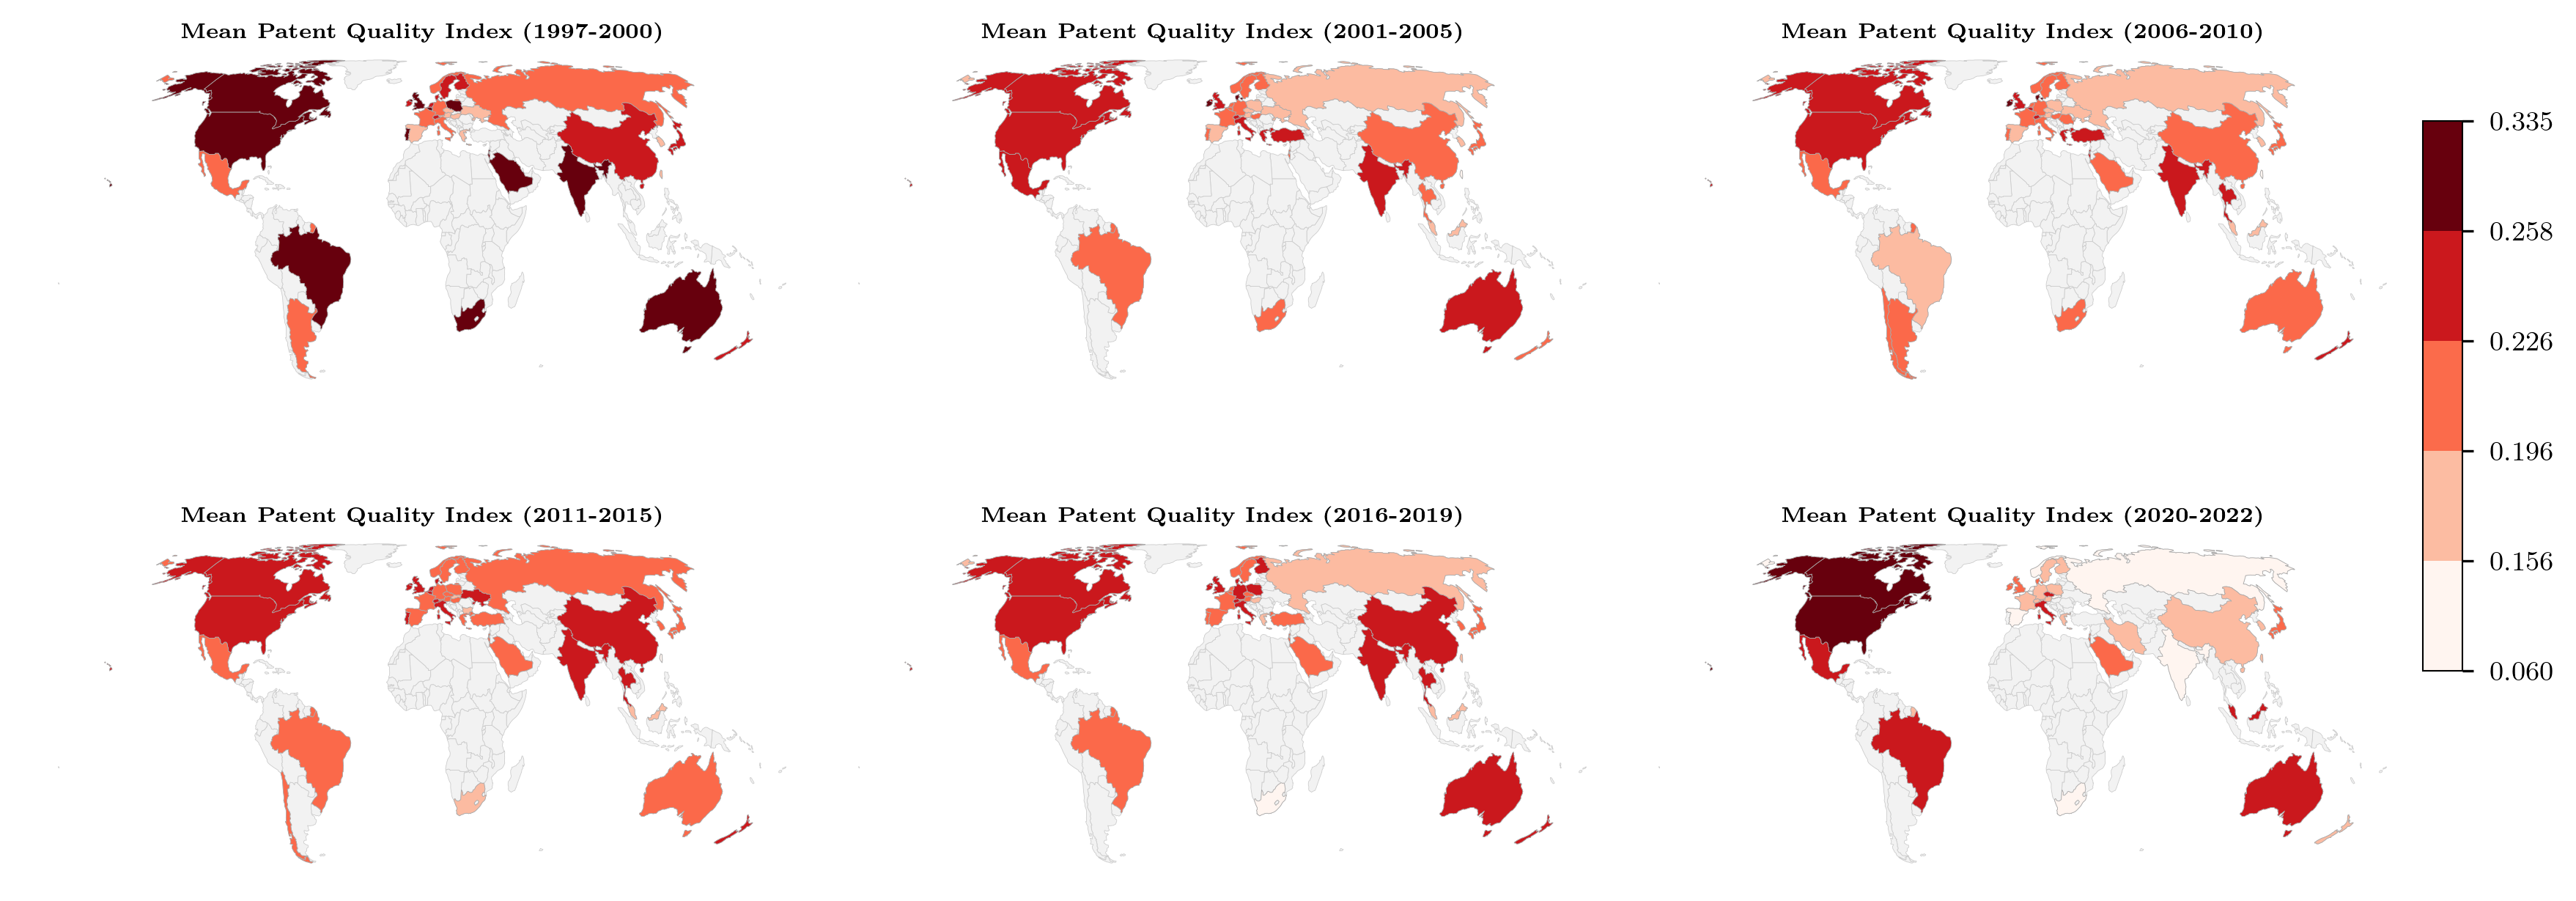

In [49]:
# ==========================================
# 4. 繪製 Small Multiples (2行3列)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()

for i, (years, label) in enumerate(time_periods):
    ax = axes[i]
    
    # 獲取該時間段的數據
    df_period = df_all_periods[df_all_periods['period'] == label].copy()
    
    # 合併到地圖數據
    world_merged = world.merge(
        df_period[['country_code_3digit', 'country_patent_quality_index']], 
        left_on='iso_a3', 
        right_on='country_code_3digit', 
        how='left'
    )
    
    # 投影轉換 (Equal Earth)
    world_proj = world_merged.to_crs('+proj=eqearth')
    
    # --- 繪圖 ---
    # 1. 繪製底圖 (淺灰)
    world_proj.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.2)
    
    # 2. 繪製數據 (Choropleth with Natural Breaks)
    world_proj.dropna(subset=['country_patent_quality_index']).plot(
        ax=ax,
        column='country_patent_quality_index',
        cmap='Reds',
        classification_kwds={'bins': breaks},  # 使用全局統一的斷點
        scheme='user_defined',  # 使用自定義斷點
        edgecolor='#aaaaaa',
        linewidth=0.2,
        legend=False
    )
    
    # 3. 設置標題和移除坐標軸
    ax.set_title(
        fr"\textbf{{Mean Patent Quality Index ({label})}}",
        fontsize=7,
        pad=2
    )
    ax.set_axis_off()

# ==========================================
# 5. 添加統一 Colorbar (使用 Natural Breaks 的斷點)
# ==========================================
cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])

# 創建離散色階
cmap = plt.cm.Reds
bounds = [quality_min] + list(breaks)
norm_discrete = mcolors.BoundaryNorm(bounds, cmap.N)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_discrete)
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', spacing='uniform')

# Colorbar 樣式
# cbar.set_label(
#     r'\textbf{Patent Quality Index}',
#     rotation=270,
#     labelpad=20,
#     fontsize=10
# )
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(labelsize=9)

# 設置刻度標籤為斷點值
cbar.set_ticks(bounds)
cbar.set_ticklabels([f'{b:.3f}' for b in bounds])

# 調整佈局
plt.subplots_adjust(wspace=0.0, hspace=0.0, left=0.01, right=0.92, bottom=0.0)

# 添加說明文字
# fig.text(
#     0.46, 0.02,
#     r'\textit{Note: Only countries contributing to top 99\% of patents in each period are shown}',
#     ha='center',
#     fontsize=8,
#     style='italic'
# )

plt.show()

### Juxtapose plots

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mapclassify
import numpy as np

# ==========================================
# 1. 設置與配置 (Configuration)
# ==========================================
def setup_style():
    """設置學術繪圖風格"""
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Computer Modern Roman"],
        "font.size": 11,
        "axes.titlesize": 10,
        "figure.dpi": 300,
    })

# 定義時間區間
TIME_PERIODS = [
    ([1997, 1998, 1999, 2000], "1997-2000"),
    ([2001, 2002, 2003, 2004, 2005], "2001-2005"),
    ([2006, 2007, 2008, 2009, 2010], "2006-2010"),
    ([2011, 2012, 2013, 2014, 2015], "2011-2015"),
    ([2016, 2017, 2018, 2019], "2016-2019"),
    ([2020, 2021, 2022], "2020-2022")
]

In [2]:


# ==========================================
# 2. 數據加載與處理模組 (Data Processing)
# ==========================================
def load_and_prep_data():
    """加載基礎地圖與數據文件"""
    # 1. 地圖數據
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world = world[(world.pop_est > 0) & (world.name != "Antarctica")]
    
    # 2. 數量數據
    df_count = pd.read_excel("expanded_patent_count.xlsx")
    # 確保年份列名
    year_col = next((col for col in df_count.columns if 'year' in col.lower()), 'earliest_year')
    df_count = df_count.rename(columns={year_col: 'year'})
    
    # 3. 質量數據
    df_quality = pd.read_csv("oecd_patent_quality_country_year.csv")
    
    return world, df_count, df_quality

def process_period_data(df_count, df_quality, periods):
    """
    處理每個時間段的數據。
    返回一個列表，包含每個時間段的 (label, quantity_df, quality_df)
    """
    processed_data = []

    for years, label in periods:
        # --- A. 處理數量 (Quantity): 計算該區間內的總和 ---
        # 篩選年份
        df_c_period = df_count[df_count['year'].isin(years)].copy()
        
        # 按國家加總
        qty_agg = df_c_period.groupby('countries_3digit')['num_patents'].sum().reset_index()
        
        # --- B. 處理質量 (Quality): 前99%產量國家的平均質量 ---
        # 1. 確定前99%的國家
        qty_agg_sorted = qty_agg.sort_values('num_patents', ascending=False)
        total_patents = qty_agg_sorted['num_patents'].sum()
        qty_agg_sorted['cumsum'] = qty_agg_sorted['num_patents'].cumsum() / total_patents
        
        valid_countries = qty_agg_sorted[qty_agg_sorted['cumsum'] <= 0.99]['countries_3digit'].tolist()
        
        # 2. 篩選質量數據
        df_q_period = df_quality[
            (df_quality['appln_filing_year'].isin(years)) &
            (df_quality['country_code_3digit'].isin(valid_countries))
        ].copy()
        
        # 3. 計算平均質量 (去除0值或無效值)
        qual_agg = df_q_period[df_q_period['country_patent_quality_index'] > 0].groupby('country_code_3digit')['country_patent_quality_index'].mean().reset_index()
        
        processed_data.append({
            'label': label,
            'years': years,
            'qty_df': qty_agg,    # 用於左圖 (Quantity)
            'qual_df': qual_agg   # 用於右圖 (Quality)
        })
        
    return processed_data

def get_global_breaks(data_list, col_key, value_col, k=6):
    """
    計算全域 Natural Breaks 以確保不同時間段的顏色可比
    """
    # 收集所有時間段的有效數值
    all_values = []
    for item in data_list:
        df = item[col_key]
        if not df.empty:
            all_values.append(df[value_col])
    
    combined_values = pd.concat(all_values)
    valid_values = combined_values[combined_values > 0]
    
    classifier = mapclassify.NaturalBreaks(valid_values, k=k)
    return list(classifier.bins), valid_values.min(), valid_values.max()

# ==========================================
# 3. 繪圖模組 (Visualization)
# ==========================================
def plot_single_map(ax, world_data, value_col, cmap, breaks, title):
    """通用單一地圖繪製函數"""
    # 投影轉換
    world_proj = world_data.to_crs('+proj=eqearth')
    
    # 1. 繪製底圖
    world_proj.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.2)
    
    # 2. 繪製數據層
    # 篩選有效數據進行繪製
    plot_data = world_proj.dropna(subset=[value_col])
    
    if not plot_data.empty:
        plot_data.plot(
            ax=ax,
            column=value_col,
            cmap=cmap,
            classification_kwds={'bins': breaks},
            scheme='user_defined',
            edgecolor='#aaaaaa',
            linewidth=0.2,
            legend=False
        )
    
    # 3. 裝飾
    ax.set_title(title, fontsize=9, pad=3)
    ax.set_axis_off()

def create_colorbar(fig, ax_bounds, cmap, breaks, data_min, fmt="{:.0f}"):
    """創建自定義 Colorbar"""
    cax = fig.add_axes(ax_bounds)
    bounds = [data_min] + breaks
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', spacing='uniform')
    cbar.outline.set_linewidth(0.5)
    cbar.ax.tick_params(labelsize=8)
    
    # 設置標籤
    cbar.set_ticks(bounds)
    if fmt == "int":
        cbar.set_ticklabels([f'{int(b):,}' for b in bounds])
    else:
        cbar.set_ticklabels([f'{b:.2f}' for b in bounds])
        
    return cbar



Loading data...


C:\Users\admin\AppData\Local\Temp\ipykernel_20428\3085001850.py:7: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Processing periods...
Calculating natural breaks...
Quantity Breaks: [1034.0, 4396.0, 10026.0, 20271.0, 28743.0, 36935.0]
Quality Breaks: [0.15552448328812635, 0.19593885332810407, 0.22629650247354033, 0.26084385801527044, 0.335194719980805]
Saving plot...


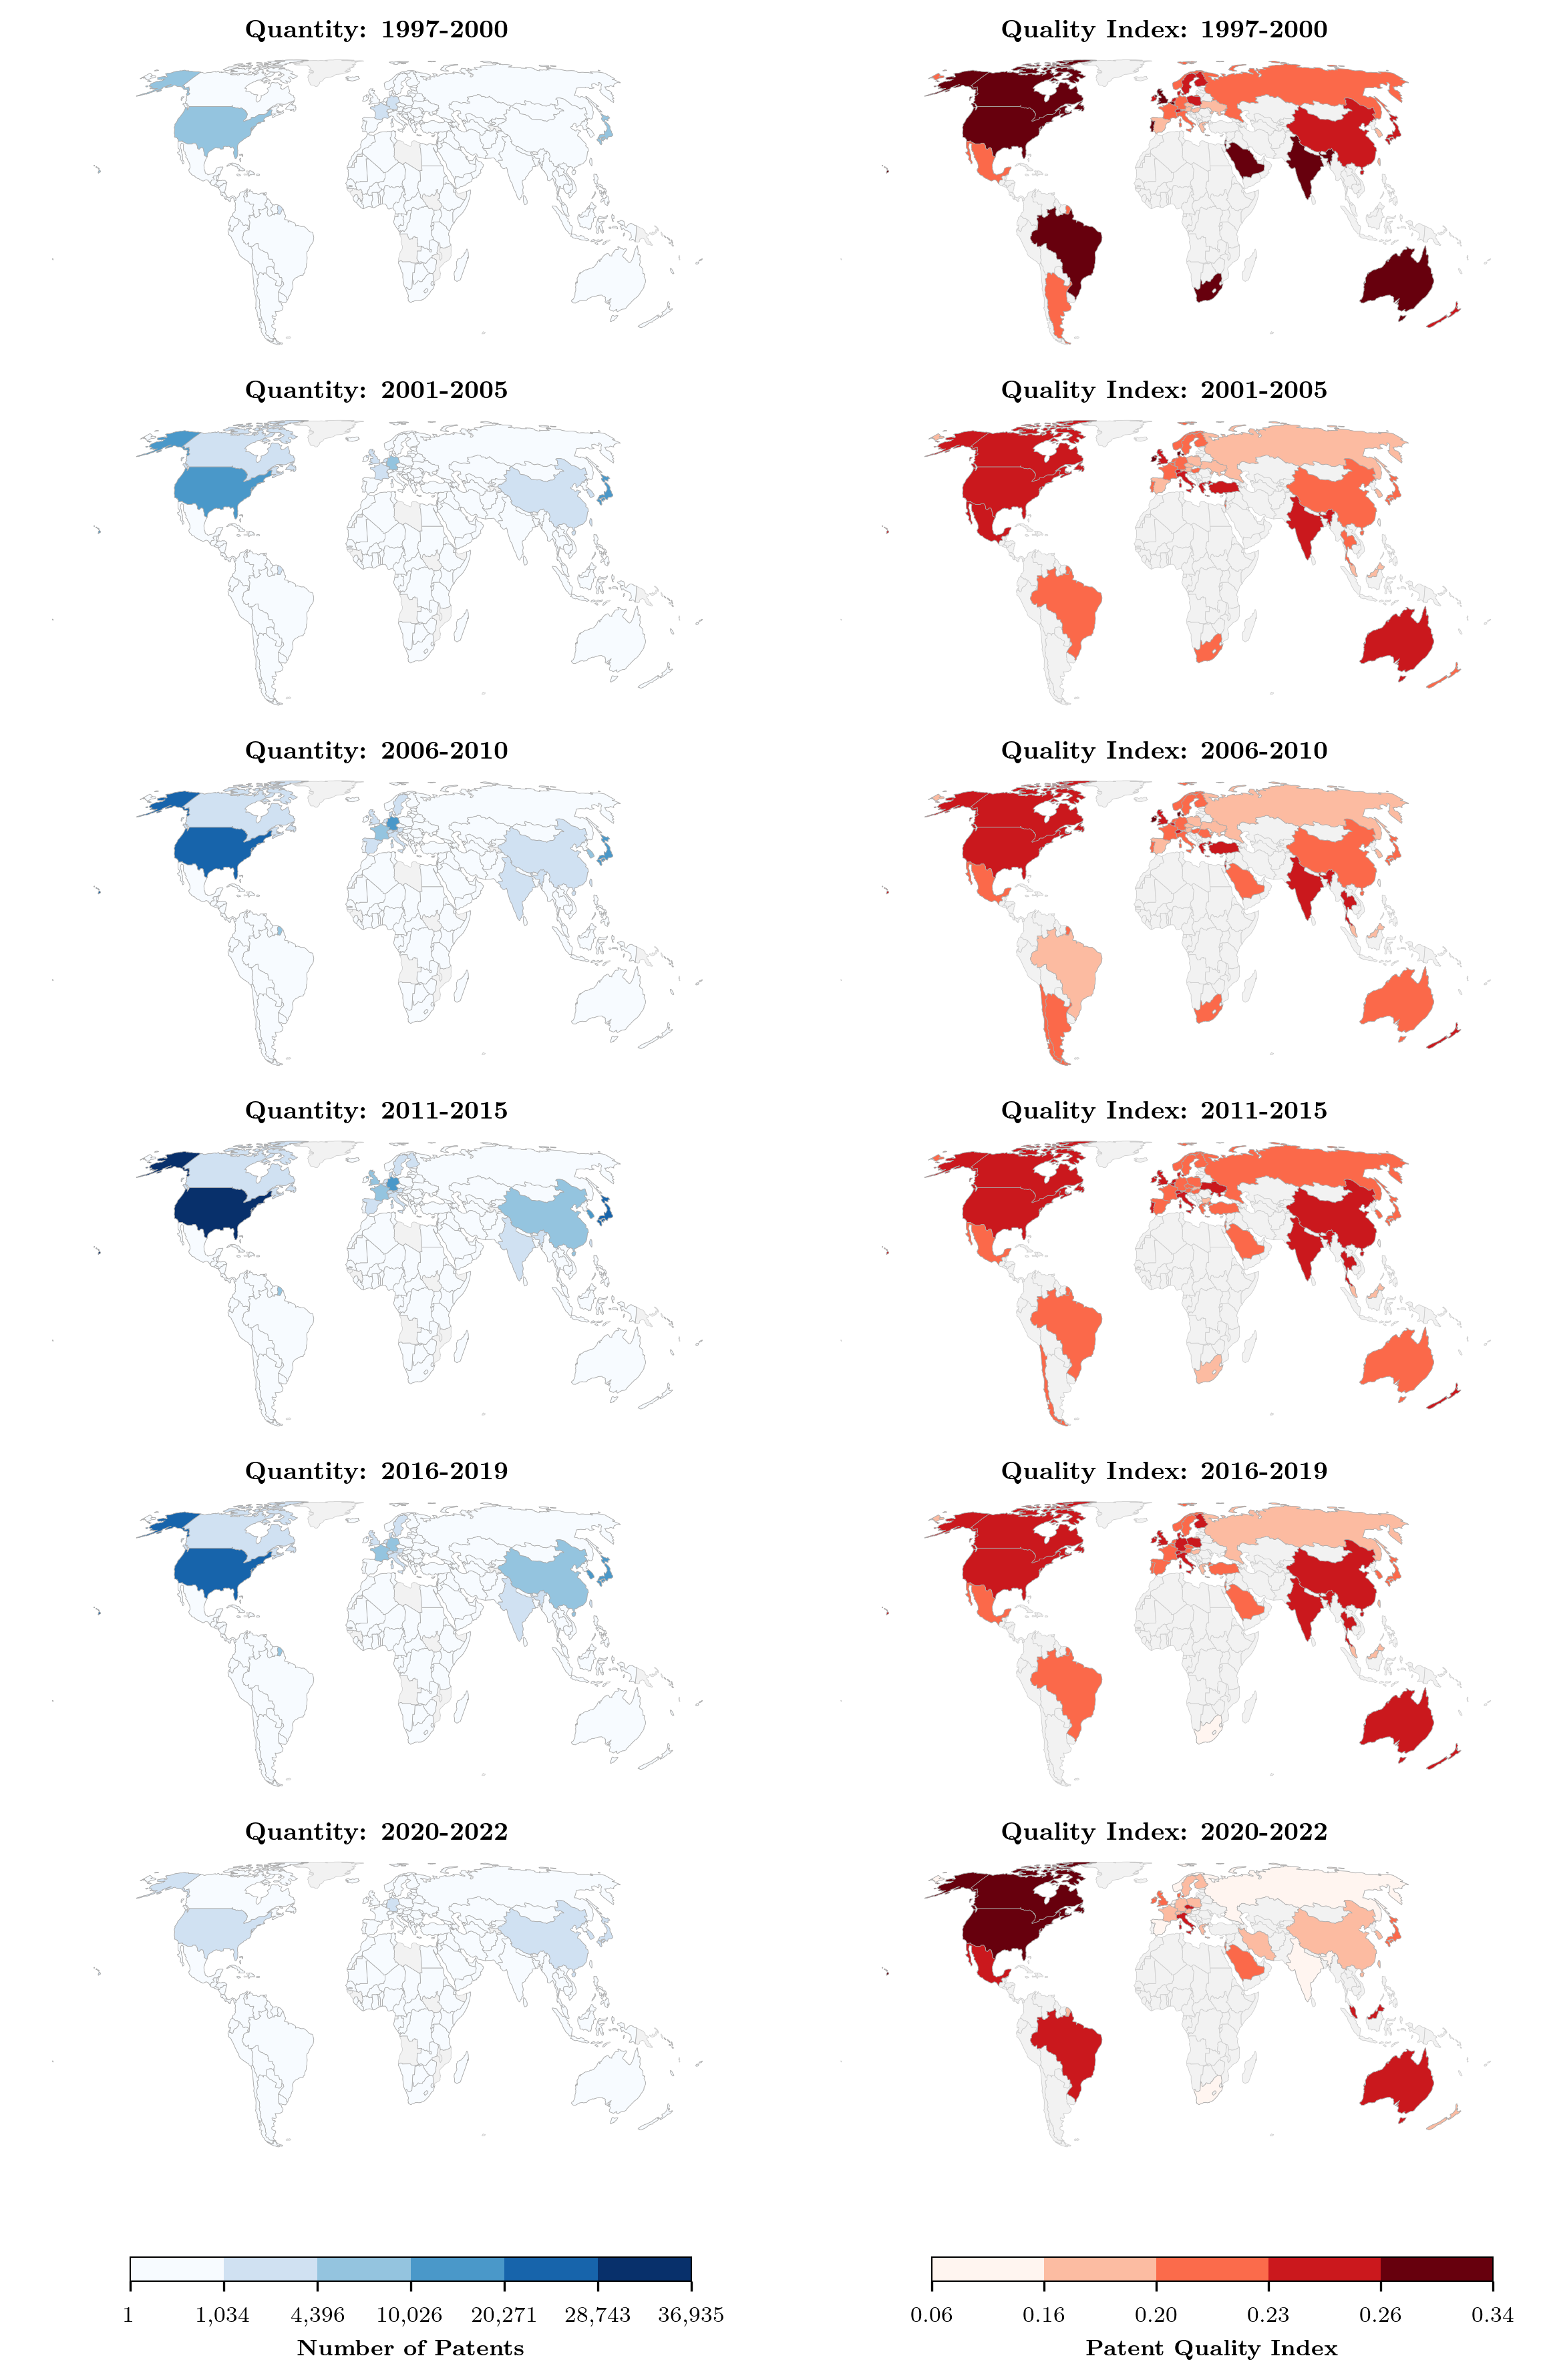

In [8]:

setup_style()

# 1. 準備數據
print("Loading data...")
world, df_count, df_quality = load_and_prep_data()

print("Processing periods...")
period_data = process_period_data(df_count, df_quality, TIME_PERIODS)

# 2. 計算全域斷點 (Global Breaks)
print("Calculating natural breaks...")
# 數量斷點 (Quantity)
qty_breaks, qty_min, _ = get_global_breaks(period_data, 'qty_df', 'num_patents', k=6)
# 質量斷點 (Quality)
qual_breaks, qual_min, _ = get_global_breaks(period_data, 'qual_df', 'country_patent_quality_index', k=5)

print(f"Quantity Breaks: {qty_breaks}")
print(f"Quality Breaks: {qual_breaks}")

# 3. 初始化畫布 (6行 x 2列)
# 增加高度以容納6行
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(8, 12))

# 4. 循環繪圖
for i, data in enumerate(period_data):
    label = data['label']
    
    # --- 左側：數量 (Quantity) ---
    ax_qty = axes[i, 0]
    # 合併地圖
    merged_qty = world.merge(data['qty_df'], left_on='iso_a3', right_on='countries_3digit', how='left')
    
    plot_single_map(
        ax_qty, 
        merged_qty, 
        'num_patents', 
        plt.cm.Blues, 
        qty_breaks, 
        fr"\textbf{{Quantity: {label}}}"
    )
    
    # --- 右側：質量 (Quality) ---
    ax_qual = axes[i, 1]
    # 合併地圖
    merged_qual = world.merge(data['qual_df'], left_on='iso_a3', right_on='country_code_3digit', how='left')
    
    plot_single_map(
        ax_qual, 
        merged_qual, 
        'country_patent_quality_index', 
        plt.cm.Reds, 
        qual_breaks, 
        fr"\textbf{{Quality Index: {label}}}"
    )

# 5. 添加 Colorbars (底部放置兩個長的 colorbar)
# 調整佈局以留出底部空間
plt.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.08, wspace=0.05, hspace=0.15)

# 數量 Colorbar (對應左列)
# [left, bottom, width, height]
cbar_qty = create_colorbar(fig, [0.1, 0.03, 0.35, 0.01], plt.cm.Blues, qty_breaks, qty_min, fmt="int")
cbar_qty.set_label(r"\textbf{Number of Patents}", fontsize=8, labelpad=5)

# 質量 Colorbar (對應右列)
cbar_qual = create_colorbar(fig, [0.6, 0.03, 0.35, 0.01], plt.cm.Reds, qual_breaks, qual_min, fmt="float")
cbar_qual.set_label(r"\textbf{Patent Quality Index}", fontsize=8, labelpad=5)

print("Saving plot...")
plt.savefig('patent_quantity_quality_comparison.png', bbox_inches='tight', dpi=300)
plt.show()